# Correlation and Regression Analysis
## Brender-Data Analyst

## Pearson Correlational Analysis

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr,spearmanr


In [3]:
data = pd.DataFrame({
    'Age':[33, 40,35,43,44,23,34,54,33],
    'Weight':[67,77,69,71,70,65,65,89,75]
})
data

,Age,Weight
0,33,67
1,40,77
2,35,69
3,43,71
4,44,70
5,23,65
6,34,65
7,54,89
8,33,75


In [5]:
#HO:There is no assocition between Age and Weight
#H1:There is assocition between Age and Weight

from scipy.stats import pearsonr

r, p_value = pearsonr(data["Age"], data["Weight"])
print(f"pearson correlation coefficient:{r:.3f}")
print(f"p_value:{p_value:.3f}")

pearson correlation coefficient:0.781
p_value:0.013


### Conclusion: Since p_value<0.05 we reject H0 and conclude that there is significant strong positive correlation between age and weight.

In [6]:
data.corr()

,Age,Weight
Age,1.000000,0.780839
Weight,0.780839,1.000000


## Calculate Spearman Correlation

In [8]:
#HO:There is no assocition between Age and Weight
#H1:There is assocition between Age and Weight

spearman_corr, spearman_p = spearmanr(data["Age"], data["Weight"])
print(f"Spearman Correlation:{spearman_corr:.3f},p_value:{spearman_p:.3f}")


Spearman Correlation:0.647,p_value:0.060


## Correlation Heatmap

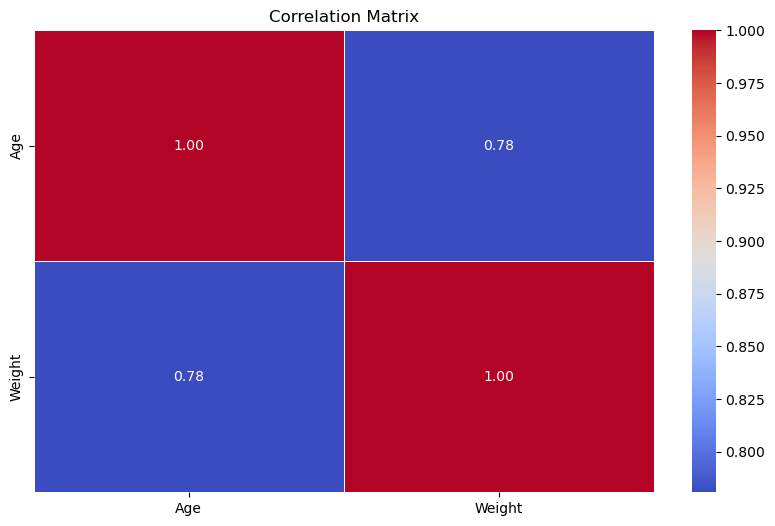

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = data.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

### Simple Linear Regression Model

In [15]:
import pandas as pd
from sklearn.linear_model import LinearRegression

data2 = pd.DataFrame({
    'Rainfall':[80,100,120,140,160],
    'Malaria_Cases':[30,40,50,60,70]
})

x = data2[['Rainfall']]
y = data2['Malaria_Cases']

model = LinearRegression()
model.fit(x,y)

print("Intercept:", model.intercept_)
print("Slope (Rainfall):", model.coef_[0])

y_pred = model.predict(x)
print("Predicted values:", y_pred)

Intercept: -10.0
Slope (Rainfall): 0.5
Predicted values: [30. 40. 50. 60. 70.]


#### y=0.5x - 10

In [16]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr,spearmanr

data = pd.DataFrame({
    'Age':[33, 40,35,43,44,23,34,54,33],
    'Weight':[67,77,69,71,70,65,65,89,75]
})


In [18]:
import statsmodels.api as sm
data

x = sm.add_constant(data['Age'])
y = data['Weight']

model = sm.OLS(y,x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     10.94
Date:                Wed, 13 May 2026   Prob (F-statistic):             0.0130
Time:                        23:49:22   Log-Likelihood:                -26.240
No. Observations:                   9   AIC:                             56.48
Df Residuals:                       7   BIC:                             56.87
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.6661      7.845      5.949      0.0

C:\Users\ADMIN\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


### Multiple Linear Regression Model

In [27]:
gss=pd.read_csv("GSSsubset.csv")
gss.head()

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,BACHELOR,60967.50,DIVORCED,53.0,72.0,190.0,60.0
1,2,FEMALE,BACHELOR,60967.50,MARRIED,26.0,60.0,97.0,40.0
2,4,FEMALE,BACHELOR,10161.25,MARRIED,56.0,68.0,160.0,20.0
3,14,FEMALE,HIGH SCHOOL,17551.25,MARRIED,40.0,65.0,156.0,37.0
4,16,MALE,HIGH SCHOOL,17551.25,MARRIED,56.0,NaN,210.0,6.0


In [28]:
x=gss[["age","height","weight","hrswrk"]]
y=gss["income"]

x = x.fillna(x.mean())

x = sm.add_constant(x)

model = sm.OLS(y,x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     61.78
Date:                Thu, 14 May 2026   Prob (F-statistic):           1.26e-46
Time:                        00:42:04   Log-Likelihood:                -11691.
No. Observations:                 994   AIC:                         2.339e+04
Df Residuals:                     989   BIC:                         2.342e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.305e+05   1.73e+04     -7.529      0.0

## Testing the Assumptions of Classical Linear Regression Models
### 1.A plot of Residuals Vs Fitted

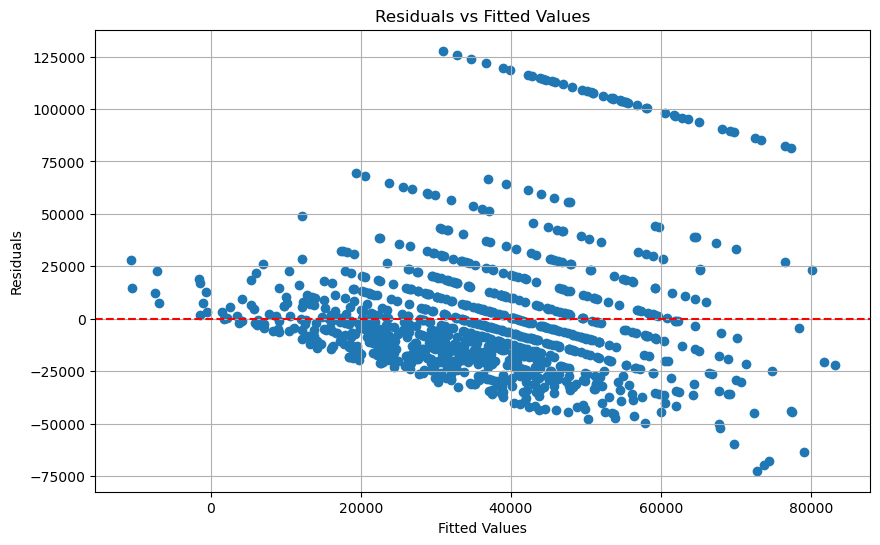

In [29]:
import matplotlib.pyplot as plt

residuals = model.resid

plt.figure(figsize=(10,6))
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.grid(True)
plt.show()

## Multicollinearity Check (Variance Inflation Factor- VIF):

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = x.columns
vif_data["VIF"] =[variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

vif_data

,Variable,VIF
0,const,308.821671
1,age,1.005407
2,height,1.327971
3,weight,1.317029
4,hrswrk,1.063403


### Normality of Regression Residuals

In [31]:
Residuals = model.resid
gss['Residuals'] = Residuals
gss.head(5)

,id,sex,degree,income,marital,age,height,weight,hrswrk,Residuals
0,1,MALE,BACHELOR,60967.50,DIVORCED,53.0,72.0,190.0,60.0,-926.185857
1,2,FEMALE,BACHELOR,60967.50,MARRIED,26.0,60.0,97.0,40.0,48832.745604
2,4,FEMALE,BACHELOR,10161.25,MARRIED,56.0,68.0,160.0,20.0,-17288.614537
3,14,FEMALE,HIGH SCHOOL,17551.25,MARRIED,40.0,65.0,156.0,37.0,-8627.917376
4,16,MALE,HIGH SCHOOL,17551.25,MARRIED,56.0,NaN,210.0,6.0,1035.590243


### Histogram Showing the Distribution of the Residuals

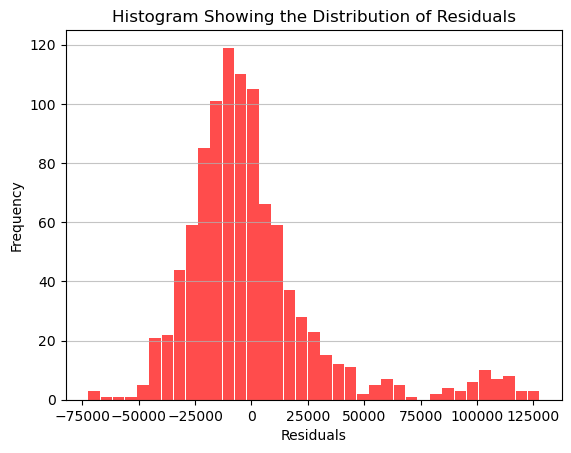

In [33]:
import matplotlib.pyplot as plt
import numpy as np

n, bins, patches = plt.hist(x=Residuals, bins='auto', color='red',
                            alpha=0.7,rwidth=0.95)
plt.grid(axis='y', alpha=0.75)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram Showing the Distribution of Residuals')
plt.show()